### 
Scenario
An education consulting company wants to build insights for students applying abroad.

Tasks
1. Analyze ranking distribution by country.
2. Identify:
○ Top universities by region
○ Countries dominating global education
○ Score trends
3. Compare rankings and academic reputation scores.
4. Find countries with the highest average university scores.
5. Build ranking-based insights for students.

Required Visualizations

Minimum 3:

● Bar Chart → Top countries by university count
● Scatter Plot → Rank vs Score
● Pie Chart → Regional distribution

Optional:

● Violin Plot
● Histogram
● Heatmap

Concepts Covered

● Ranking analysis
● Aggregation
● Sorting
● Descriptive statistics
● Comparative analytics

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [5]:
df=pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Review\QS_World_University_Rankings_2025_Top_global_universities (1).csv",encoding='latin1')

In [6]:
df

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,1,1,Massachusetts Institute of Technology (MIT),United States,Americas,M,CO,VH,B,100.0,...,100,86.8,143,96.0,58,100.0,8,99.0,15=,100
1,2,6,Imperial College London,United Kingdom,Europe,L,FC,VH,A,98.5,...,66,99.6,44,97.4,34,93.4,61,99.7,6,98.5
2,3,3,University of Oxford,United Kingdom,Europe,L,FC,VH,A,100.0,...,120,97.7,73,100.0,1,100.0,3,85.0,126,96.9
3,4,4,Harvard University,United States,Americas,L,FC,VH,B,100.0,...,269,69.0,215,99.6,5,100.0,1,84.4,130,96.8
4,5,2,University of Cambridge,United Kingdom,Europe,L,FC,VH,A,100.0,...,73,94.8,98,99.3,10,100.0,5,84.8,127=,96.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1498,1401+,1201-1400,University of Montana Missoula,United States,Americas,M,CO,HI,A,3.0,...,701+,1.9,701+,6.5,701+,3.1,701+,1.0,701+,NaN
1499,1401+,1401+,University of Oradea,Romania,Europe,L,FC,MD,A,5.6,...,701+,5.2,701+,34.5,701+,6.2,701+,2.3,701+,NaN
1500,1401+,1201-1400,University of San Carlos,Philippines,Asia,M,CO,MD,C,7.2,...,701+,2.1,701+,6.4,701+,9.6,701+,1.0,701+,NaN
1501,1401+,1401+,"University Politehnica of Timisoara, UPT",Romania,Europe,L,FO,VH,A,4.1,...,701+,2.5,701+,18.6,701+,3.9,701+,1.1,701+,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             1503 non-null   str    
 1   RANK_2024                             1482 non-null   str    
 2   Institution_Name                      1503 non-null   str    
 3   Location                              1503 non-null   str    
 4   Region                                1503 non-null   str    
 5   SIZE                                  1503 non-null   str    
 6   FOCUS                                 1503 non-null   str    
 7   RES.                                  1503 non-null   str    
 8   STATUS                                1466 non-null   str    
 9   Academic_Reputation_Score             1503 non-null   float64
 10  Academic_Reputation_Rank              1503 non-null   str    
 11  Employer_Reputation_Score   

In [13]:
df['RANK_2025']=pd.to_numeric(df['RANK_2025'],errors='coerce')
df['RANK_2024']=pd.to_numeric(df['RANK_2024'],errors='coerce')

In [39]:
df.isna()

,RANK_2025,RANK_2024,Institution_Name,Location,Region,SIZE,FOCUS,RES.,STATUS,Academic_Reputation_Score,...,International_Faculty_Rank,International_Students_Score,International_Students_Rank,International_Research_Network_Score,International_Research_Network_Rank,Employment_Outcomes_Score,Employment_Outcomes_Rank,Sustainability_Score,Sustainability_Rank,Overall_Score
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1498,True,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1499,True,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1500,True,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1501,True,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [41]:
df.dropna(inplace=True)

In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 564 entries, 0 to 599
Data columns (total 28 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   RANK_2025                             564 non-null    float64
 1   RANK_2024                             564 non-null    float64
 2   Institution_Name                      564 non-null    str    
 3   Location                              564 non-null    str    
 4   Region                                564 non-null    str    
 5   SIZE                                  564 non-null    str    
 6   FOCUS                                 564 non-null    str    
 7   RES.                                  564 non-null    str    
 8   STATUS                                564 non-null    str    
 9   Academic_Reputation_Score             564 non-null    float64
 10  Academic_Reputation_Rank              564 non-null    str    
 11  Employer_Reputation_Score          

In [ ]:
#Analyze ranking distribution by country
sorted_df= df.sort_values("RANK_2025",ascending=True)
rank_universities=sorted_df.drop_duplicates(subset='Location')
rank_universities.head(10)
display(rank_universities[['RANK_2025','Location']].head(10))


,RANK_2025,Location
0,1.0,United States
1,2.0,United Kingdom
6,7.0,Switzerland
7,8.0,Singapore
12,13.0,Australia
13,14.0,China (Mainland)
16,17.0,Hong Kong SAR
23,24.0,France
24,25.0,Canada
27,28.0,Germany


- Top universities by region

In [144]:
top_10_universities = df.sort_values('RANK_2025').head(30)
top_10_by_region = top_10_universities[['Region', 'RANK_2025', 'Institution_Name']].sort_values('Region')
top_10_by_region

,Region,RANK_2025,Institution_Name
0,Americas,1.0,Massachusetts Institute of Technology (MIT)
24,Americas,25.0,University of Toronto
22,Americas,23.0,Yale University
3,Americas,4.0,Harvard University
21,Americas,22.0,Princeton University
5,Americas,6.0,Stanford University
20,Americas,21.0,University of Chicago
9,Americas,10.0,California Institute of Technology (Caltech)
10,Americas,11.0,University of Pennsylvania
11,Americas,12.0,"University of California, Berkeley (UCB)"


Countries dominating global education

In [135]:
country_dominance = df['Region'].value_counts().head(10)
country_dominance

Region
Europe      236
Asia        161
Americas    122
Oceania      38
Africa        7
Name: count, dtype: int64

- Compare rankings and academic reputation scores.

<Axes: xlabel='RANK_2025', ylabel='Academic_Reputation_Score'>

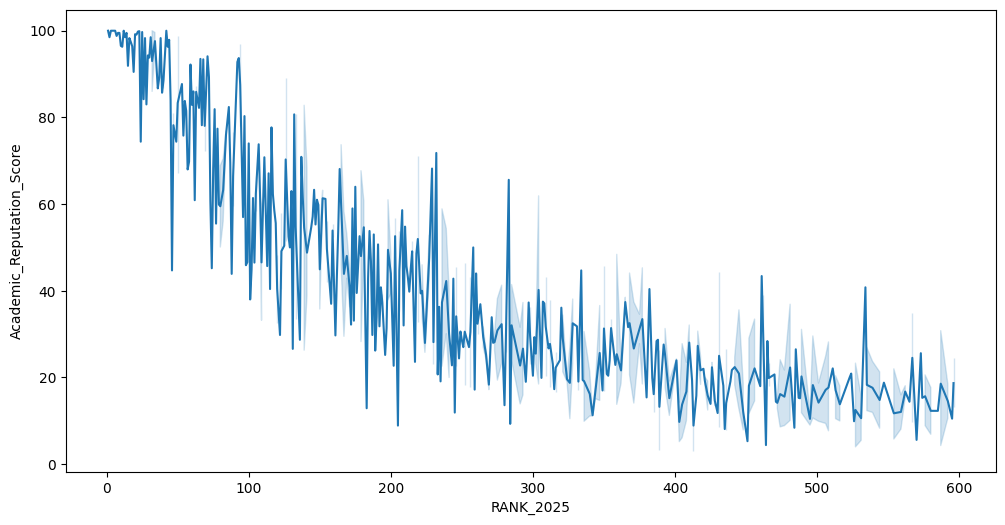

In [152]:
plt.figure(figsize=(12, 6))
sns.lineplot(df, x='RANK_2025', y='Academic_Reputation_Score')

In [86]:

Universities_count=df.value_counts('Location').head(10).reset_index()
Universities_count.columns=['Location','Institution count']
Universities_count

,Location,Institution count
0,United States,84
1,United Kingdom,55
2,China (Mainland),35
3,Germany,31
4,Australia,30
5,Canada,19
6,Italy,18
7,France,17
8,Spain,17
9,South Korea,16


In [117]:
df['Overall_Score']=pd.to_numeric(df['Overall_Score'],errors='coerce')

- Find countries with the highest average university scores.

In [119]:
#Compute average score per Country using pandas.
score_region=df.groupby(by='Location')['Overall_Score']
average_score=score_region.mean()
top_10_scores = average_score.sort_values(ascending=False).head(10)
top_10_scores

Location
Hong Kong SAR    71.516667
Singapore        67.766667
Mexico           54.750000
Switzerland      54.277778
Qatar            52.000000
Netherlands      51.730769
Sweden           50.987500
Japan            49.778571
Australia        49.500000
United States    48.907143
Name: Overall_Score, dtype: float64

- Bar Chart → Top countries by university count

In [98]:
fig = px.bar(Universities_count,
             x='Location',
             y='Institution count', 
             title='<b>Top 10 Countries with the Most  Universities</b>',
             labels={'Institution count'':Number of Universities'},
             color='Institution count')

fig.update_layout(xaxis_title='Country',
                  yaxis_title='Number of Universities'
                  )
fig.show()

-  Scatter Plot → Rank vs Score

In [103]:
fig=px.scatter(df,
               x='RANK_2025',
               y='Overall_Score',
               title="<b>Relationship between Rank vs Score</b>",
               labels={'RANK_2025':'Overall_Rank_in_2025','Overall_Score':'Institutional_Overall_Score'}
               
            )
fig.update_layout(title_font_size=25)
fig.show()

In [114]:
region_data = df['Region'].value_counts()
region_data

Region
Europe      236
Asia        161
Americas    122
Oceania      38
Africa        7
Name: count, dtype: int64

- Pie Chart → Regional distribution


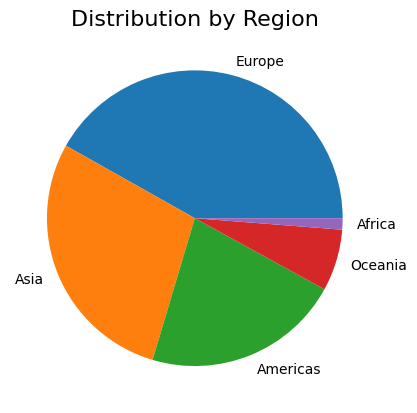

In [153]:
plt.Figure(figsize=(8,6))
plt.pie(region_data,labels=region_data.index)
plt.title('Distribution by Region', fontsize=16)
plt.show()